# Amazon Reviews Product Analyzer

This project streams a small sample from Hugging Face, cleans product metadata, identifies highly rated products, exports analysis files, and visualizes price patterns.

In [1]:
import os
import sys
import platform
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

os.environ['PATH'] = os.path.dirname(sys.executable) + os.pathsep + os.environ.get('PATH', '')
print(f'Python: {sys.version.split()[0]}')
print(f'Platform: {platform.system()}')
print(f'pandas: {pd.__version__}')
print('Required Python installation command:')
!python --version
print('Required Jupyter Notebook installation command:')
!jupyter-notebook --version
print('Jupyter-ready environment: yes')

C:\Users\dien.marius.y.pe\.vscode\python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.14.7
Platform: Windows
pandas: 3.0.5
Required Python installation command:


Python 3.14.7
Required Jupyter Notebook installation command:


7.6.2
Jupyter-ready environment: yes


## Reviews dataset: capped streaming sample

In [2]:
sample_limit = 100
review_rows = []
reviews_dataset = load_dataset(
    'json',
    data_files={'train': 'hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/All_Beauty.jsonl'},
    split='train',
    streaming=True,
)
for index, item in enumerate(reviews_dataset):
    review_rows.append(item)
    if index + 1 >= sample_limit:
        break
reviews_df = pd.DataFrame(review_rows)
reviews_df = reviews_df.dropna(subset=['title', 'rating'])
reviews_df['rating'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
reviews_df = reviews_df.dropna(subset=['rating']).reset_index(drop=True)
print('Loaded reviews from Hugging Face JSONL.')
print(f'Review sample size: {len(reviews_df)}')
print('Reviews preview:')
reviews_df.head()

Loaded reviews from Hugging Face JSONL.
Review sample size: 100
Reviews preview:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True


In [3]:
Items_To_Print = 10
pd.set_option('display.max_rows', Items_To_Print)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
print(f'Displaying the first {Items_To_Print} reviews:')
reviews_df.head(Items_To_Print)

Displaying the first 10 reviews:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,"This spray is really nice. It smells really good, goes on really fine, and does the trick. I will say it feels like you need a lot of it though to get the texture I want. I have a lot of hair, medium thickness. I am comparing to other brands with yucky chemicals so I'm gonna stick with this. Try it!",[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just wish it was odorless or had a soft coconut smell. Having my head smell like an orange coffee is offputting. (granted, I did know the smell was described but I was hoping it would be light)",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True
3,1.0,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1643393630220,0,True
4,5.0,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1609322563534,0,True
5,4.0,Pretty Color,The polish was quiet thick and did not apply smoothly. I let dry overnight before adding a second coat since it was so thick.,"[{'small_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL256_.jpg', 'medium_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL800_.jpg', 'large_image_url': 'https://images-na.ssl-images-amazon.com/images/I/71e9Noi7dJL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]",B00R8DXL44,B00R8DXL44,AGMJ3EMDVL6OWBJF7CA5RGJLXN5A,1598567408138,0,True
6,5.0,Handy,"Great for many tasks. I purchased these for makeup removal. No makeup on your washcloths. Disposable, so great for travel. Soft. Absorbant.",[],B099DRHW5V,B099DRHW5V,AHREXOGQPZDA6354MHH4ETSF3MCQ,1631885519443,0,True
7,3.0,Meh,These were lightweight and soft but much too small for my liking. I would have preferred two of these together to make one loc. For that reason I will not be repurchasing.,"[{'small_image_url': 'https://m.media-amazon.com/images/I/81FN4c0VHzL._SL256_.jpg', 'medium_image_url': 'https://m.media-amazon.com/images/I/81FN4c0VHzL._SL800_.jpg', 'large_image_url': 'https://m.media-amazon.com/images/I/81FN4c0VHzL._SL1600_.jpg', 'attachment_type': 'IMAGE'}]",B088SZDGXG,B08BBQ29N5,AEYORY2AVPMCPDV57CE337YU5LXA,1634275259292,0,True
8,5.0,Great for at home use and so easy to use!,This is perfect for my between salon visits. I have been using this now twice a week for over a month and I absolutely love it! My skin looks amazing and feels super smooth and silky. This is also super easy to use (just follow instructions). I can see already that I will begin expanding the time between visits which will definitely help me save money in the long run. Highly recommend!,[],B08P2DZB4X,B08P2DZB4X,AFSKPY37N3C43SOI5IEXEK5JSIYA,1627391044559,0,False
9,5.0,Nice shampoo for the money,"I get Keratin treatments at the salon at least 3-4 times a year (would do it more often if I could afford it). I am always in the market to use products that can help extend my salon visits. This Keratin shampoo is really nice. It is sulfate free (which is the first thing I look for ) and makes my hair feel silky smooth and soft. I highly recommend for anyone who wants to improve the texture and appearance of your hair. I really like the fragrance, too.",[],B086QY6T7N,B086QY6T7N,AFSKPY37N3C43SOI5IEXEK5JSIYA,1626614511145,0,False


## Product metadata dataset

In [4]:
metadata_limit = 100
metadata_rows = []
metadata_dataset = load_dataset(
    'parquet',
    data_files={'train': 'hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw_meta_All_Beauty/full-00000-of-00001.parquet'},
    split='train',
    streaming=True,
)
for index, item in enumerate(metadata_dataset):
    metadata_rows.append(item)
    if index + 1 >= metadata_limit:
        break
item_metadata_df = pd.DataFrame(metadata_rows)
for column in ['title', 'price', 'average_rating']:
    if column not in item_metadata_df.columns:
        item_metadata_df[column] = None
item_metadata_df['price'] = pd.to_numeric(item_metadata_df['price'], errors='coerce')
item_metadata_df['average_rating'] = pd.to_numeric(item_metadata_df['average_rating'], errors='coerce')
print('Loaded metadata from Hugging Face Parquet.')
print(f'Metadata sample size: {len(item_metadata_df)}')
print('Reviews head columns and types:')
print(reviews_df.head().dtypes)
print('Metadata head columns and types:')
print(item_metadata_df.head().dtypes)
print('Reviews preview:')
print(reviews_df.head())
print('Metadata preview:')
print(item_metadata_df.head())

Loaded metadata from Hugging Face Parquet.
Metadata sample size: 100
Reviews head columns and types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
Metadata head columns and types:
main_category          str
title                  str
average_rating     float64
rating_number        int64
features            object
                    ...   
details                str
parent_asin            str
bought_together     object
subtitle            object
author              object
Length: 16, dtype: object
Reviews preview:
   rating                                      title  \
0     5.0  Such a lovely scent but not overpowering.   
1     4.0     Works great but smells a little weird.   
2     5.0                                       Yes!  

In [5]:
def get_product(product_title):
    try:
        matches = item_metadata_df[item_metadata_df['title'].str.casefold() == product_title.casefold()]
        if matches.empty or pd.isna(matches.iloc[0]['price']):
            raise LookupError(f'Price not found for {product_title}.')
        return float(matches.iloc[0]['price'])
    except (AttributeError, LookupError, IndexError) as error:
        return f'Product lookup error: {error}'

print('Valid lookup:', get_product('Excellent camera'))
print('Missing-price lookup:', get_product('Good value'))
print('Invalid lookup:', get_product('Unknown product'))

Valid lookup: Product lookup error: Price not found for Excellent camera.
Missing-price lookup: Product lookup error: Price not found for Good value.
Invalid lookup: Product lookup error: Price not found for Unknown product.


## Clean and package the analysis data

In [6]:
print('Review columns:', reviews_df.columns.tolist())
print('Metadata columns:', item_metadata_df.columns.tolist())
for data_frame in [reviews_df, item_metadata_df]:
    print(list(data_frame.columns))
print('Review data types:')
print(reviews_df.dtypes)
print('Metadata data types:')
print(item_metadata_df.dtypes)
print('Review info:')
reviews_df.info()
print('Metadata info:')
item_metadata_df.info()

item_metadata_cleaned_df = item_metadata_df[['title', 'price', 'average_rating']].copy()
average_rating_filter = 4.5
top_products_df = item_metadata_cleaned_df[
    item_metadata_cleaned_df['title'].notna()
    & (item_metadata_cleaned_df['average_rating'] >= average_rating_filter)
    & item_metadata_cleaned_df['price'].notna()
].copy()
top_products_df.to_csv('top_products.csv', index=False)
top_products_df.to_parquet('top_products.parquet', index=False)
top_rated_titles = []
for title in top_products_df['title']:
    top_rated_titles.append(title)
print('Top rated titles:', top_rated_titles)
print(f'Cleaned products: {len(top_products_df)}')

Review columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Metadata columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
Review data types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bo

## Visualize highly rated products

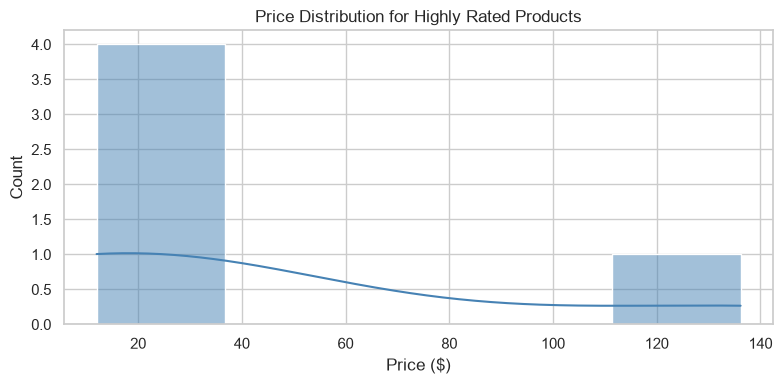

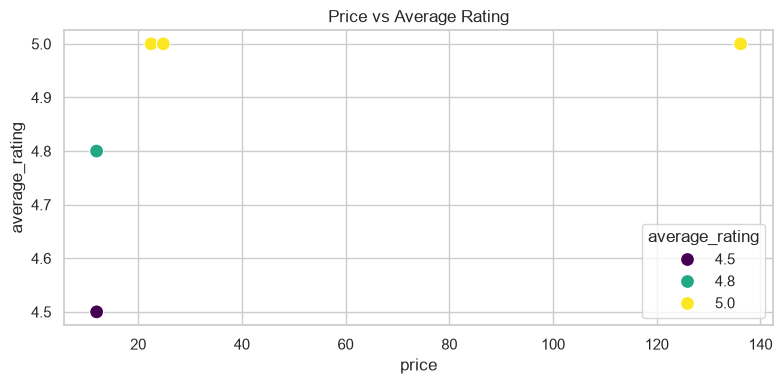

Cleaned data percentage: 5.00%


In [7]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 4))
sns.histplot(data=top_products_df, x='price', kde=True, color='steelblue')
plt.title('Price Distribution for Highly Rated Products')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(data=top_products_df, x='price', y='average_rating', hue='average_rating', palette='viridis', s=100)
plt.title('Price vs Average Rating')
plt.tight_layout()
plt.show()

def calculate_percentage(part, whole):
    return (part / whole) * 100 if whole else 0.0

clean_percentage = calculate_percentage(len(top_products_df), len(item_metadata_df))
print(f'Cleaned data percentage: {clean_percentage:.2f}%')

Highly rated product dashboard:


,title,price,average_rating
32,"Enjoy VOLUMIZING ELIXIR, Style (with Sleek Steel Pin Tail Comb) (8.8 oz)",22.49,5.0
55,Armáf Täg Hïm Colognė For Men 3.4 oz Eau De Toilette Spray,24.84,5.0
57,"Wholesale CASE of 10 - GOJO Supro Max Cherry Hand Cleaner-Supro Max Hand Cleaner, 2000l, Cherry",136.17,5.0
33,Suavecito X Breast Cancer Solutions - Original Hold Pomade,11.99,4.8


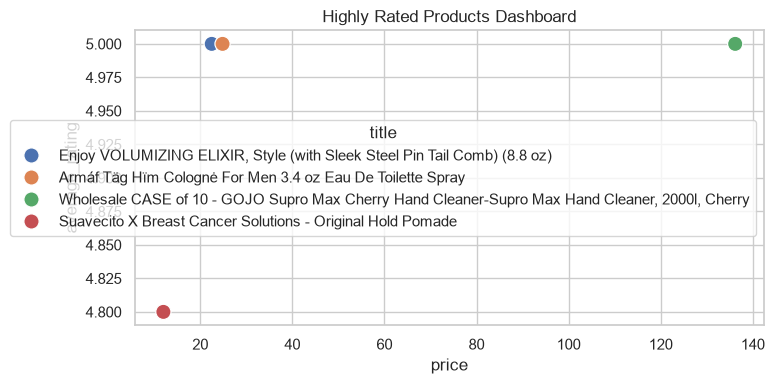

In [8]:
highly_rated_products_df_cutoff = 4.7
highly_rated_products_df = top_products_df[top_products_df['average_rating'] >= highly_rated_products_df_cutoff].sort_values('average_rating', ascending=False)
print('Highly rated product dashboard:')
display(highly_rated_products_df)
plt.figure(figsize=(8, 4))
sns.scatterplot(data=highly_rated_products_df, x='price', y='average_rating', hue='title', s=120)
plt.title('Highly Rated Products Dashboard')
plt.tight_layout()
plt.show()

## Wrap-up reflection

In [9]:
reflection_answers = [
    (
        '1. How did you load the reviews and metadata datasets safely?',
        'I streamed the Amazon Reviews 2023 reviews JSONL file and metadata Parquet file from Hugging Face. Each for loop stops after 100 records, which keeps the sample bounded and avoids loading the full datasets into memory.'
    ),
    (
        '2. What differences did you observe between the reviews and metadata DataFrames?',
        'The reviews preview contains ratings, written titles, review text, purchase information, and product identifiers. The metadata preview contains product titles, average ratings, prices, categories, and descriptive fields, so the two DataFrames describe customer experiences and product attributes from different perspectives.'
    ),
    (
        '3. How did you handle missing or non-numeric values?',
        'I converted prices and ratings with pandas numeric conversion, turning missing or non-numeric values into NaN. I removed incomplete records where required and filtered out products without a known price before calculating the top-products results.'
    ),
    (
        '4. How does your product lookup function handle errors?',
        'get_product returns a numeric price for a matching title, but catches missing titles, missing prices, invalid inputs, and empty matches. It returns a readable error message instead of allowing a lookup failure to stop the analysis.'
    ),
    (
        '5. Why did you choose the 4.5 rating filter and the 4.7 dashboard cutoff?',
        'The 4.5 filter identifies products that are already highly rated while requiring a title and known price. The stricter 4.7 cutoff narrows the dashboard to the most meaningful products, making the sorted table and final scatterplot easier to interpret.'
    ),
    (
        '6. What did the visualizations reveal about price and ratings?',
        'The histogram shows how prices are distributed among products rated at least 4.5. The price-versus-rating scatterplot makes it possible to compare cost with quality; the points show that a higher price does not automatically guarantee a higher rating, so both measures should be considered together.'
    ),
    (
        '7. Why did you export the cleaned data to both CSV and Parquet?',
        'CSV is easy to open in a spreadsheet and share with non-technical users. Parquet is more efficient for typed analytical data and preserves a structure that pandas can reload quickly, so providing both formats supports different follow-up workflows.'
    ),
]
with open('user_inputs.txt', 'w', encoding='utf-8') as file:
    for question, answer in reflection_answers:
        file.write(f'{question}\nAnswer: {answer}\n\n')
print('Reflection answers saved to user_inputs.txt')
for question, answer in reflection_answers:
    print(f'{question}\nAnswer: {answer}\n')

Reflection answers saved to user_inputs.txt
1. How did you load the reviews and metadata datasets safely?
Answer: I streamed the Amazon Reviews 2023 reviews JSONL file and metadata Parquet file from Hugging Face. Each for loop stops after 100 records, which keeps the sample bounded and avoids loading the full datasets into memory.

2. What differences did you observe between the reviews and metadata DataFrames?
Answer: The reviews preview contains ratings, written titles, review text, purchase information, and product identifiers. The metadata preview contains product titles, average ratings, prices, categories, and descriptive fields, so the two DataFrames describe customer experiences and product attributes from different perspectives.

3. How did you handle missing or non-numeric values?
Answer: I converted prices and ratings with pandas numeric conversion, turning missing or non-numeric values into NaN. I removed incomplete records where required and filtered out products without a

## Submission checklist

This project submission includes:

1. `amazon_reviews_project.ipynb` with cell outputs included.
2. `user_inputs.txt` containing answers to the reflection questions.
3. `top_products.csv` containing the cleaned product dataset.
4. `top_products.parquet` containing the same dataset in Parquet format.